# Preliminaries

In [1]:
import torch
import torch.optim as optim 
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import torch.nn.functional as F 
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# Get training data
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_loader = DataLoader(dataset=training_data, batch_size=128,shuffle=True)

# Dimension of 28x28 

# The network

In [4]:
# Define model, encoder decoder seperately
class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.f_mu = nn.Linear(hidden_dim,latent_dim)
        self.f_logvar = nn.Linear(hidden_dim,latent_dim)

        # We use a stack here to make iterating on the model sligthly easier
        self.encoder_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self,x):
        enc_stack = self.encoder_stack(x)
        mu = self.f_mu(enc_stack)
        f_logvar = self.f_logvar(enc_stack)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.decoder_stack= nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        output = self.decoder_stack(x)
        return output


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(input_dim, hidden_dim, latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar
    

# Training the model

In [5]:
def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss

Epoch 1, Loss: 163.8343
Epoch 2, Loss: 121.3810
Epoch 3, Loss: 114.6179
Epoch 4, Loss: 111.7153
Epoch 5, Loss: 109.8659
Epoch 6, Loss: 108.6900
Epoch 7, Loss: 107.8232
Epoch 8, Loss: 107.1241
Epoch 9, Loss: 106.6750
Epoch 10, Loss: 106.2701


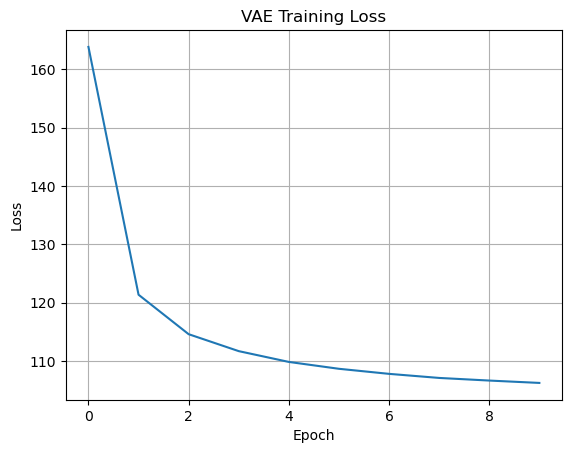

In [6]:
epochs = 10
learning_rate = 1e-3

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



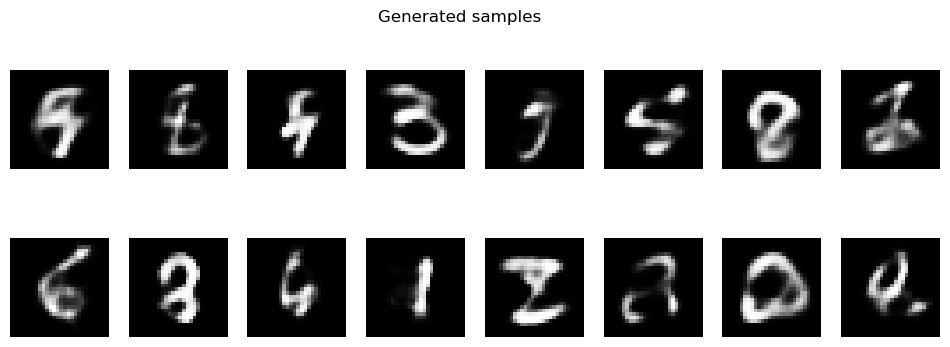

In [7]:
model.eval()

with torch.no_grad():
    z = torch.randn((16,20)).to(device)

    generated = model.decoder(z).cpu()
    generated = generated.view(-1,1,28,28)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()

# Latent space visualisation

In [8]:
model.eval()
features = []
labels = []
# visualise with PCA
with torch.no_grad():
    for batch_idx, (x, label) in enumerate(train_loader):
        x = x.view(-1, 784).to(device)
        mu, logvar = model.encoder(x)
        features.append(mu)
        labels.append(label)

# cats along the right dimension
features = torch.cat(features, dim=0)
labels = torch.cat(labels, dim=0)

U,S,V=torch.pca_lowrank(features, q=2)

train_2d = torch.matmul(features, V[:,:2])
# pass to cpu for plotting
train_2d = train_2d.to("cpu")
labels = labels.to("cpu")

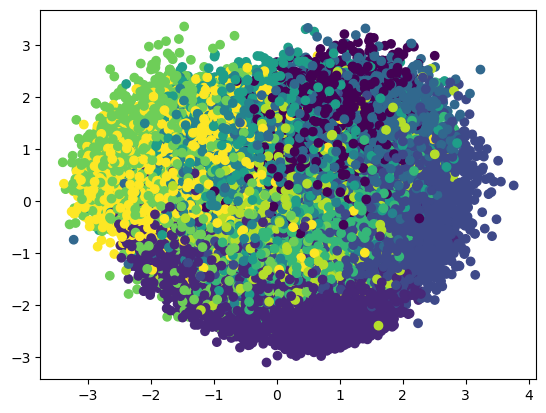

In [10]:
fig, ax = plt.subplots()

ax.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')

plt.show()

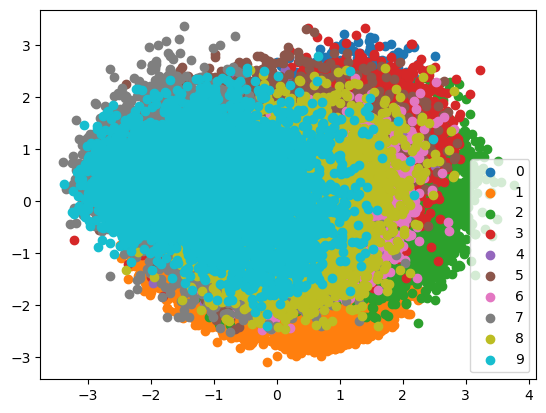

In [ ]:
import matplotlib as mpl 

n_lines = 10
cmap = mpl.colormaps['tab10']
colors = [cmap(i) for i in range(10)]
# slightly convoluted way to do the plot
classes = list(range(0,10))

for cls in classes:
    indices = [i for i, c in enumerate(labels) if c == cls]
    subset = torch.utils.data.Subset(train_2d, indices)
    subset = torch.stack([t for t in subset])
    plt.scatter(subset[:,0],subset[:,1], label=cls, color=colors[cls])

#indices = [i for i, c in enumerate(labels) if c == 1]
#display(indices)
#plt.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')
#plt.gca().legend(('1','2','3','4','5','6','7','8'))


plt.legend()
plt.show()


# Sampling from a given class

Idea: figure out the mean parameters for a given class and then use the decoder to generate new numbers basd off this.

In [13]:
# Simple example: class of sixes

indices = [i for i, (e,c) in enumerate(training_data) if c == 1]
sample__set = torch.utils.data.Subset(training_data, indices)

# make a data loader for simpler computation, not sure if necessary (probably not!)
sample_set_loader = DataLoader(dataset=training_data, batch_size=128,shuffle=True)

In [37]:
# Basically reusing code from before
model.eval()

means = []
vars = []

with torch.no_grad():
    for batch_idx, (x, label) in enumerate(sample_set_loader):
        x = x.view(-1, 784).to(device)
        mu, logvar = model.encoder(x)
        
        means.append(mu)
        # to make it sampleable
        vars.append(torch.exp(0.5*logvar))

# flatten the means and variations 
means = torch.cat(means, dim=0)
vars = torch.cat(vars, dim=0)
        

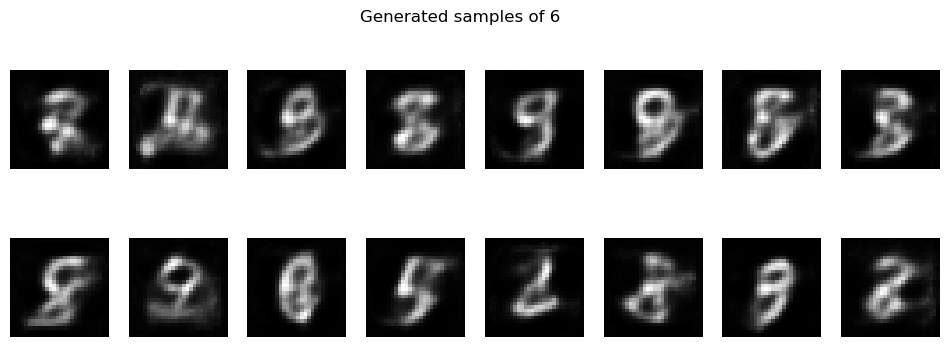

In [42]:
mean = torch.mean(means, dim=0)
var = torch.mean(vars, dim=0)

# sample a few images
with torch.no_grad():
    z = torch.randn((16,20)).to(device)
    # modify to dist using mu+var*z
    class_dist = mean + var*z

    generated = model.decoder(class_dist).cpu()
    generated = generated.view(-1,1,28,28)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples of 6")
plt.show()

Looking at the PCA and the above plots makes me personally feel the model is slightly lacking. This is roughly expected though as it is very simple. 

# More robust model

We will still use MNIST but we will instead use convolution. For convenience, we will resize the images slighty.

In [97]:
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor
from torchvision.transforms import Resize

base_images = datasets.MNIST(
    root="data",
    train=True,
    download="True",
    # resizing images to make them big enough
    transform=Compose([Resize(32),
                       ToTensor()])
    #transform=ToTensor(),
)

base_loader = DataLoader(dataset=base_images, batch_size=128,shuffle=True)

In [105]:
# Define model, encoder decoder seperately

class Encoder(nn.Module):
    # allows for hidden layer etc. experimentation
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        self.f_mu = nn.Linear(2048,latent_dim)
        self.f_logvar = nn.Linear(2048,latent_dim)

        self.encoder_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

    def forward(self,x):
        enc_stack = self.encoder_stack(x)
        mu = self.f_mu(enc_stack)
        f_logvar = self.f_logvar(enc_stack)

        return mu, f_logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        #hidden_dim = 128*(28//8)*(28//8)
        #display(hidden_dim)
        pre_flatten_shape = (128, 4, 4)
        # fully connected layer
        self.fc1 = nn.Linear(latent_dim, 2048)
        # define a helper to reshape to allow for tensor operations
        self.reshape = lambda x: x.view(-1, *pre_flatten_shape)

        self.decoder_stack= nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3,stride=2,padding=1, output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3,stride=2,padding=1,output_padding= 1),
            nn.ReLU(),
            nn.Sigmoid()
        )        

    def forward(self,x): 
        x = self.fc1(x)
        x = self.reshape(x)
        
        x = self.decoder_stack(x)
        
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # needed to make the gradients flow
    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5*logvar) # standard deviation
        eps = torch.randn_like(std) # random noise
        return mu+eps*std   # sample

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z= self.reparameterise(mu,logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar
    

In [125]:
def loss_function(recon_x, x, mu, logvar):
    # reconstruction loss (binary cross entropy)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    return recon_loss + kl_loss.mean()

In [134]:


epochs = 100
learning_rate = 1e-3

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, "min")

train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(base_loader):
        x= x.to(device)
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)
        loss = loss_function(recon_x, x, mu, logvar)
        optimizer.step()
        loss.backward()
        
        total_loss += loss.item()
    avg_loss = total_loss/len(train_loader.dataset)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



Epoch 1, Loss: 709.8013
Epoch 2, Loss: 709.8015
Epoch 3, Loss: 709.8016
Epoch 4, Loss: 709.8015
Epoch 5, Loss: 709.8012
Epoch 6, Loss: 709.8016
Epoch 7, Loss: 709.8014
Epoch 8, Loss: 709.8016
Epoch 9, Loss: 709.8016
Epoch 10, Loss: 709.8016


KeyboardInterrupt: 

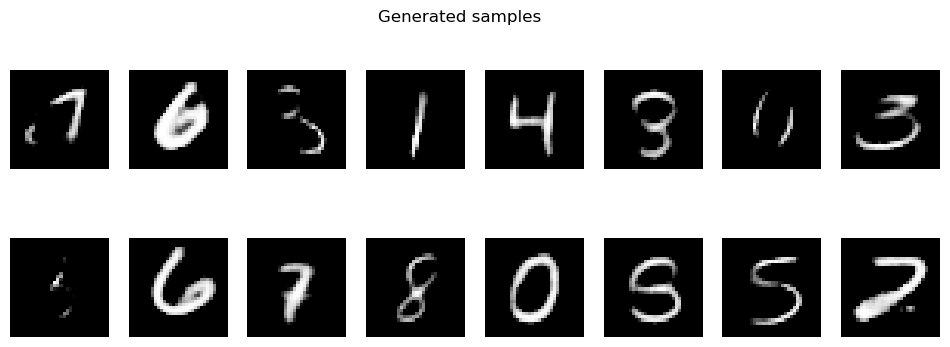

In [120]:
model.eval()

with torch.no_grad():
    z = torch.randn((16,20)).to(device)

    generated = model.decoder(z).cpu()
    generated = generated.view(-1,1,32,32)

# plot generated samples
fig, axes = plt.subplots(2,8,figsize=(12,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray')
    ax.axis('off')

plt.suptitle("Generated samples")
plt.show()

In [122]:
model.eval()
features = []
labels = []
# visualise with PCA
with torch.no_grad():
    for batch_idx, (x, label) in enumerate(base_loader):
        x = x.to(device)
        mu, logvar = model.encoder(x)
        features.append(mu)
        labels.append(label)

# cats along the right dimension
features = torch.cat(features, dim=0)
labels = torch.cat(labels, dim=0)

U,S,V=torch.pca_lowrank(features, q=2)

train_2d = torch.matmul(features, V[:,:2])
# pass to cpu for plotting
train_2d = train_2d.to("cpu")
labels = labels.to("cpu")

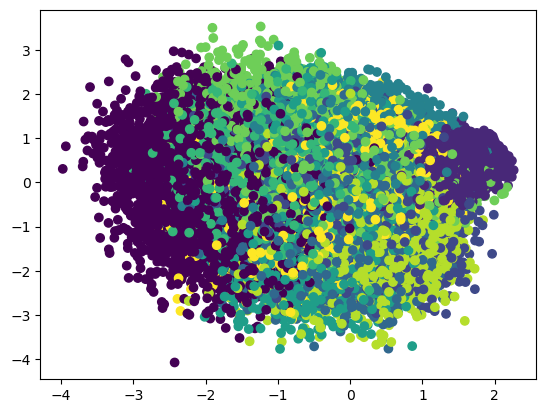

In [123]:
fig, ax = plt.subplots()

ax.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')

plt.show()

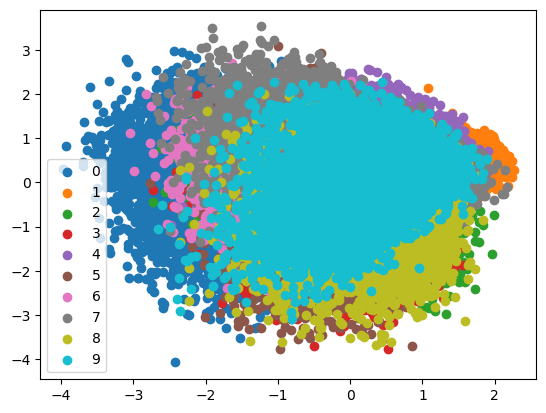

In [124]:
import matplotlib as mpl 

n_lines = 10
cmap = mpl.colormaps['tab10']
colors = [cmap(i) for i in range(10)]
# slightly convoluted way to do the plot
classes = list(range(0,10))

for cls in classes:
    indices = [i for i, c in enumerate(labels) if c == cls]
    subset = torch.utils.data.Subset(train_2d, indices)
    subset = torch.stack([t for t in subset])
    plt.scatter(subset[:,0],subset[:,1], label=cls, color=colors[cls])

#indices = [i for i, c in enumerate(labels) if c == 1]
#display(indices)
#plt.scatter(train_2d[:,0], train_2d[:,1],c=labels, cmap='viridis')
#plt.gca().legend(('1','2','3','4','5','6','7','8'))


plt.legend()
plt.show()